In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
application_test = pd.read_csv("home-credit-default-risk/application_test.csv")
application_train = pd.read_csv("home-credit-default-risk/application_train.csv")
bureau = pd.read_csv("home-credit-default-risk/bureau.csv")
bureau_balance = pd.read_csv("home-credit-default-risk/bureau_balance.csv")
credit_card_balance = pd.read_csv("home-credit-default-risk/credit_card_balance.csv")
installments_payments = pd.read_csv("home-credit-default-risk/installments_payments.csv")
POS_CASH_balance = pd.read_csv("home-credit-default-risk/POS_CASH_balance.csv")
previous_application = pd.read_csv("home-credit-default-risk/previous_application.csv")
sample_submission = pd.read_csv("home-credit-default-risk/sample_submission.csv")

In [3]:
application_train.shape

(307511, 122)

In [4]:
application_train["ORGANIZATION_TYPE"]

0         Business Entity Type 3
1                         School
2                     Government
3         Business Entity Type 3
4                       Religion
                   ...          
307506                  Services
307507                       XNA
307508                    School
307509    Business Entity Type 1
307510    Business Entity Type 3
Name: ORGANIZATION_TYPE, Length: 307511, dtype: object

In [83]:
for df in [application_train, application_test]:
    # Mittelwert der drei Quellen
    df['EXT_SOURCE_mean'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
    df['EXT_SOURCE_min'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].min(axis=1)
    df['EXT_SOURCE_max'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].max(axis=1)

    # Paarweise Produkte
    #df['EXT_SOURCE_1_2'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2']
    #df['EXT_SOURCE_1_3'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_3']
    #df['EXT_SOURCE_2_3'] = df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']
    df['EXT_SOURCE_1_2_3'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']

    # Verhältnis Kredit zu Einkommen
    df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
    df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)

    #Trend: Viele neue Anfragen?
    df['enquiry_recent_vs_old'] = (df['AMT_REQ_CREDIT_BUREAU_WEEK'] + df['AMT_REQ_CREDIT_BUREAU_MON']) / (df['AMT_REQ_CREDIT_BUREAU_YEAR'] + 1)



In [6]:
#bureau.csv

In [7]:
bureau.shape

(1716428, 17)

In [8]:
bureau.columns

Index(['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY',
       'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE',
       'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG',
       'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT',
       'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE',
       'AMT_ANNUITY'],
      dtype='object')

In [9]:
bureau["SK_ID_CURR"].nunique()

305811

In [10]:
bureau.head(15)

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.00,0.00,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.00,171342.00,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.50,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.00,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.00,NaN,NaN,0.0,Consumer credit,-21,NaN
5,215354,5714467,Active,currency 1,-273,0,27460.0,NaN,0.0,0,180000.00,71017.38,108982.62,0.0,Credit card,-31,NaN
6,215354,5714468,Active,currency 1,-43,0,79.0,NaN,0.0,0,42103.80,42103.80,0.00,0.0,Consumer credit,-22,NaN
7,162297,5714469,Closed,currency 1,-1896,0,-1684.0,-1710.0,14985.0,0,76878.45,0.00,0.00,0.0,Consumer credit,-1710,NaN
8,162297,5714470,Closed,currency 1,-1146,0,-811.0,-840.0,0.0,0,103007.70,0.00,0.00,0.0,Consumer credit,-840,NaN
9,162297,5714471,Active,currency 1,-1146,0,-484.0,NaN,0.0,0,4500.00,0.00,0.00,0.0,Credit card,-690,NaN


In [11]:
bureau["CREDIT_ACTIVE"].value_counts()

CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64

In [12]:
bureau.isnull().sum().sort_values(ascending=False)

AMT_ANNUITY               1226791
AMT_CREDIT_MAX_OVERDUE    1124488
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_SUM_LIMIT       591780
AMT_CREDIT_SUM_DEBT        257669
DAYS_CREDIT_ENDDATE        105553
AMT_CREDIT_SUM                 13
CREDIT_ACTIVE                   0
CREDIT_CURRENCY                 0
DAYS_CREDIT                     0
CREDIT_DAY_OVERDUE              0
SK_ID_BUREAU                    0
CNT_CREDIT_PROLONG              0
AMT_CREDIT_SUM_OVERDUE          0
CREDIT_TYPE                     0
DAYS_CREDIT_UPDATE              0
SK_ID_CURR                      0
dtype: int64

In [13]:
#AMT_ANNUITY und AMT_CREDIT_MAX_OVERDUE haben mehr als 50% NA Werte
bureau.drop(columns=['AMT_ANNUITY', "AMT_CREDIT_MAX_OVERDUE"], inplace=True)

In [14]:
#AMT_CREDIT_SUM hat nur 13 NA Werte. Diese Zeilen droppen wir einfach
bureau = bureau.dropna(subset=["AMT_CREDIT_SUM"])

In [15]:
bureau["CREDIT_ACTIVE"].value_counts()

CREDIT_ACTIVE
Closed      1079268
Active       630599
Sold           6527
Bad debt         21
Name: count, dtype: int64

In [16]:
#bureau_balance

In [17]:
bureau_balance.shape

(27299925, 3)

In [18]:
bureau_balance.columns

Index(['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS'], dtype='object')

In [19]:
bureau_balance.describe()

,SK_ID_BUREAU,MONTHS_BALANCE
count,2.729992e+07,2.729992e+07
mean,6.036297e+06,-3.074169e+01
std,4.923489e+05,2.386451e+01
min,5.001709e+06,-9.600000e+01
25%,5.730933e+06,-4.600000e+01
50%,6.070821e+06,-2.500000e+01
75%,6.431951e+06,-1.100000e+01
max,6.842888e+06,0.000000e+00


In [20]:
bureau_balance["STATUS"].value_counts()

STATUS
C    13646993
0     7499507
X     5810482
1      242347
5       62406
2       23419
3        8924
4        5847
Name: count, dtype: int64

In [ ]:
bureau_balance["is_active"] = (bureau_balance["STATUS"] == "0").astype(int) #Anzahl aktiver Monate

In [21]:
#Aggregation bureau_balance mit bureau

In [22]:
bureau_balance_agg = bureau_balance.groupby("SK_ID_BUREAU").agg(
    bb_months_count=("MONTHS_BALANCE", "count"),      # wie viele Monate Daten vorhanden
    bb_max_dpd=("STATUS", lambda x: x[x.isin(["1","2","3","4","5"])].astype(float).max()),  # schlimmster DPD Status
    bb_bad_months=("STATUS", lambda x: x.isin(["4","5"]).sum()),  # Monate mit ernstem Verzug

    bb_active_no_dpd_months=("is_active", "sum"),  # Absolute Anzahl aktiver Monate
    bb_active_no_dpd_ratio=("is_active", "mean")   # Prozentualer Anteil aktiver Monate
).reset_index()
#Ratio von schlechten Monaten
bureau_balance_agg["bb_bad_ratio"] = bureau_balance_agg["bb_bad_months"] / (bureau_balance_agg["bb_months_count"] + 1)

bureau = bureau.merge(bureau_balance_agg, on="SK_ID_BUREAU", how="left")

In [23]:
bureau.describe()

,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT_UPDATE,bb_months_count,bb_max_dpd,bb_bad_months
count,1.716415e+06,1.716415e+06,1.716415e+06,1.716415e+06,1.610871e+06,1.082770e+06,1.716415e+06,1.716415e+06,1.458746e+06,1.124648e+06,1.716415e+06,1.716415e+06,774349.000000,98651.000000,774349.000000
mean,2.782147e+05,5.924434e+06,-1.142115e+03,8.181728e-01,5.105173e+02,-1.017441e+03,6.410454e-03,3.549946e+05,1.370825e+05,6.229515e+03,3.791304e+01,-5.937526e+02,31.225889,1.321629,0.071518
std,1.029384e+05,5.322663e+05,7.951627e+02,3.654457e+01,4.994226e+03,7.140102e+02,9.622427e-02,1.149811e+06,6.774004e+05,4.503203e+04,5.937673e+03,7.207484e+02,23.483787,0.924993,1.397812
min,1.000010e+05,5.000000e+06,-2.922000e+03,0.000000e+00,-4.206000e+04,-4.202300e+04,0.000000e+00,0.000000e+00,-4.705600e+06,-5.864061e+05,0.000000e+00,-4.194700e+04,1.000000,1.000000,0.000000
25%,1.888665e+05,5.463952e+06,-1.666000e+03,0.000000e+00,-1.138000e+03,-1.489000e+03,0.000000e+00,5.130000e+04,0.000000e+00,0.000000e+00,0.000000e+00,-9.080000e+02,12.000000,1.000000,0.000000
50%,2.780550e+05,5.926301e+06,-9.870000e+02,0.000000e+00,-3.300000e+02,-8.970000e+02,0.000000e+00,1.255185e+05,0.000000e+00,0.000000e+00,0.000000e+00,-3.950000e+02,25.000000,1.000000,0.000000
75%,3.674250e+05,6.385682e+06,-4.740000e+02,0.000000e+00,4.740000e+02,-4.250000e+02,0.000000e+00,3.150000e+05,4.015350e+04,0.000000e+00,0.000000e+00,-3.300000e+01,45.000000,1.000000,0.000000
max,4.562550e+05,6.843457e+06,0.000000e+00,2.792000e+03,3.119900e+04,0.000000e+00,9.000000e+00,5.850000e+08,1.701000e+08,4.705600e+06,3.756681e+06,3.720000e+02,97.000000,5.000000,89.000000


In [24]:
debt_cols = ["AMT_CREDIT_SUM_DEBT", "AMT_CREDIT_SUM", "AMT_CREDIT_SUM_OVERDUE"]

for col in debt_cols:
    upper = bureau[col].quantile(0.999)
    bureau[col] = bureau[col].clip(upper=upper)

In [25]:
bureau_agg = bureau.groupby("SK_ID_CURR").agg(
    bureau_loan_count=("SK_ID_BUREAU", "count"),    #Anzahl Kredite
    bureau_active_count=("CREDIT_ACTIVE", lambda x: (x == "Active").sum()), #Anzahl Aktive Kredite
    bureau_total_credit=("AMT_CREDIT_SUM", "sum"),  #Gesamtkreditehöhe
    bureau_total_debt=("AMT_CREDIT_SUM_DEBT", "sum"),   #Gesamtschulden
    bureau_current_debt=("AMT_CREDIT_SUM_OVERDUE", "sum"),  #Aktuelle Schulden

    bureau_avg_credit_age=("DAYS_CREDIT", "mean"),       # wie lange zurück die Kredite sind
    bureau_most_recent_credit=("DAYS_CREDIT", "max"),    # jüngster Kredit
    bureau_oldest_credit=("DAYS_CREDIT", "min"),         # ältester Kredit

    bureau_avg_credit=("AMT_CREDIT_SUM", "mean"),
    bureau_max_credit=("AMT_CREDIT_SUM", "max"),

    bb_months_count = ("bb_months_count", "sum"),
    bb_max_dpd=("bb_max_dpd", "max"),
    bb_bad_months=("bb_bad_months", "sum"),
).reset_index()

print(application_train.shape)

(307511, 128)


In [26]:
print(bureau_agg.shape)

(305809, 14)


In [27]:
application_train.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EXT_SOURCE_mean,EXT_SOURCE_min,EXT_SOURCE_max,EXT_SOURCE_1_2_3,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,265992.000000,265992.000000,265992.000000,265992.000000,307339.000000,3.073390e+05,307339.000000,1.095890e+05,307511.000000,307499.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.034362,0.267395,0.265474,1.899974,0.509251,3.995821e-01,0.615882,1.433152e-01,3.957537,0.180928
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.204685,0.916002,0.794056,1.869295,0.149802,1.874246e-01,0.156130,1.075977e-01,2.689696,0.094573
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000006,8.173617e-08,0.000006,2.430332e-07,0.004808,0.000224
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.413648,2.539628e-01,0.540654,5.610600e-02,2.018659,0.114781
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,1.000000,0.524502,4.031671e-01,0.648470,1.199324e-01,3.265042,0.162832
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,3.000000,0.622819,5.530128e-01,0.725276,2.101258e-01,5.159857,0.229064
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,8.000000,27.000000,261.000000,25.000000,0.878903,8.789034e-01,0.962693,6.185571e-01,84.733539,1.875892


In [28]:
#es gab eine Fehlerhafte Zeile wo jemand seit 1000 Jahren angestellt war
application_train['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

In [29]:
#credit card balance

In [30]:
credit_card_balance.shape

(3840312, 23)

In [31]:
credit_card_balance.head(15)

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.500,0.0,877.500,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.000,0.0,0.000,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.000,0.0,0.000,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.000,0.0,0.000,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.000,0.0,11547.000,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0
5,2646502,380010,-7,82903.815,270000,0.0,0.000,0.0,0.000,4449.105,...,82773.315,82773.315,0.0,0,0.0,0.0,2.0,Active,7,0
6,1079071,171320,-6,353451.645,585000,67500.0,67500.000,0.0,0.000,14684.175,...,351881.145,351881.145,1.0,1,0.0,0.0,6.0,Active,0,0
7,2095912,118650,-7,47962.125,45000,45000.0,45000.000,0.0,0.000,0.000,...,47962.125,47962.125,1.0,1,0.0,0.0,51.0,Active,0,0
8,2181852,367360,-4,291543.075,292500,90000.0,289339.425,0.0,199339.425,130.500,...,286831.575,286831.575,3.0,8,0.0,5.0,3.0,Active,0,0
9,1235299,203885,-5,201261.195,225000,76500.0,111026.700,0.0,34526.700,6338.340,...,197224.695,197224.695,3.0,9,0.0,6.0,38.0,Active,0,0


In [32]:
credit_card_balance.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE',
       'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT',
       'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT',
       'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY',
       'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT',
       'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE',
       'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT',
       'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT',
       'CNT_INSTALMENT_MATURE_CUM', 'NAME_CONTRACT_STATUS', 'SK_DPD',
       'SK_DPD_DEF'],
      dtype='object')

In [33]:
credit_card_balance.describe()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,SK_DPD,SK_DPD_DEF
count,3.840312e+06,3.840312e+06,3.840312e+06,3.840312e+06,3.840312e+06,3.090496e+06,3.840312e+06,3.090496e+06,3.090496e+06,3.535076e+06,...,3.840312e+06,3.840312e+06,3.840312e+06,3.090496e+06,3.840312e+06,3.090496e+06,3.090496e+06,3.535076e+06,3.840312e+06,3.840312e+06
mean,1.904504e+06,2.783242e+05,-3.452192e+01,5.830016e+04,1.538080e+05,5.961325e+03,7.433388e+03,2.881696e+02,2.968805e+03,3.540204e+03,...,5.596588e+04,5.808881e+04,5.809829e+04,3.094490e-01,7.031439e-01,4.812496e-03,5.594791e-01,2.082508e+01,9.283667e+00,3.316220e-01
std,5.364695e+05,1.027045e+05,2.666775e+01,1.063070e+05,1.651457e+05,2.822569e+04,3.384608e+04,8.201989e+03,2.079689e+04,5.600154e+03,...,1.025336e+05,1.059654e+05,1.059718e+05,1.100401e+00,3.190347e+00,8.263861e-02,3.240649e+00,2.005149e+01,9.751570e+01,2.147923e+01
min,1.000018e+06,1.000060e+05,-9.600000e+01,-4.202502e+05,0.000000e+00,-6.827310e+03,-6.211620e+03,0.000000e+00,0.000000e+00,0.000000e+00,...,-4.233058e+05,-4.202502e+05,-4.202502e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.434385e+06,1.895170e+05,-5.500000e+01,0.000000e+00,4.500000e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00
50%,1.897122e+06,2.783960e+05,-2.800000e+01,0.000000e+00,1.125000e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.500000e+01,0.000000e+00,0.000000e+00
75%,2.369328e+06,3.675800e+05,-1.100000e+01,8.904669e+04,1.800000e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.633911e+03,...,8.535924e+04,8.889949e+04,8.891451e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00
max,2.843496e+06,4.562500e+05,-1.000000e+00,1.505902e+06,1.350000e+06,2.115000e+06,2.287098e+06,1.529847e+06,2.239274e+06,2.028820e+05,...,1.472317e+06,1.493338e+06,1.493338e+06,5.100000e+01,1.650000e+02,1.200000e+01,1.650000e+02,1.200000e+02,3.260000e+03,3.260000e+03


In [34]:
credit_card_balance.isnull().sum().sort_values(ascending=False)

AMT_PAYMENT_CURRENT           767988
AMT_DRAWINGS_ATM_CURRENT      749816
CNT_DRAWINGS_POS_CURRENT      749816
AMT_DRAWINGS_OTHER_CURRENT    749816
AMT_DRAWINGS_POS_CURRENT      749816
CNT_DRAWINGS_OTHER_CURRENT    749816
CNT_DRAWINGS_ATM_CURRENT      749816
CNT_INSTALMENT_MATURE_CUM     305236
AMT_INST_MIN_REGULARITY       305236
SK_ID_PREV                         0
AMT_TOTAL_RECEIVABLE               0
SK_DPD                             0
NAME_CONTRACT_STATUS               0
CNT_DRAWINGS_CURRENT               0
AMT_PAYMENT_TOTAL_CURRENT          0
AMT_RECIVABLE                      0
AMT_RECEIVABLE_PRINCIPAL           0
SK_ID_CURR                         0
AMT_DRAWINGS_CURRENT               0
AMT_CREDIT_LIMIT_ACTUAL            0
AMT_BALANCE                        0
MONTHS_BALANCE                     0
SK_DPD_DEF                         0
dtype: int64

In [35]:
credit_card_balance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int64  
 1   SK_ID_CURR                  int64  
 2   MONTHS_BALANCE              int64  
 3   AMT_BALANCE                 float64
 4   AMT_CREDIT_LIMIT_ACTUAL     int64  
 5   AMT_DRAWINGS_ATM_CURRENT    float64
 6   AMT_DRAWINGS_CURRENT        float64
 7   AMT_DRAWINGS_OTHER_CURRENT  float64
 8   AMT_DRAWINGS_POS_CURRENT    float64
 9   AMT_INST_MIN_REGULARITY     float64
 10  AMT_PAYMENT_CURRENT         float64
 11  AMT_PAYMENT_TOTAL_CURRENT   float64
 12  AMT_RECEIVABLE_PRINCIPAL    float64
 13  AMT_RECIVABLE               float64
 14  AMT_TOTAL_RECEIVABLE        float64
 15  CNT_DRAWINGS_ATM_CURRENT    float64
 16  CNT_DRAWINGS_CURRENT        int64  
 17  CNT_DRAWINGS_OTHER_CURRENT  float64
 18  CNT_DRAWINGS_POS_CURRENT    float64
 19  CNT_INSTALMENT_MATURE

In [36]:
credit_card_balance["utilization_rate"] = (
    credit_card_balance["AMT_BALANCE"] /
    (credit_card_balance["AMT_CREDIT_LIMIT_ACTUAL"] + 1)
)
#negative Werte möglich

In [37]:
credit_card_balance[credit_card_balance["AMT_BALANCE"] < 0].head(20)

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF,utilization_rate
17248,1249602,446446,-43,-428.040,45000,0.0,0.0,0.0,0.0,0.000,...,-428.040,0.0,0,0.0,0.0,17.0,Active,0,0,-0.009512
17250,1390845,198928,-45,-395.055,180000,0.0,0.0,0.0,0.0,0.000,...,-395.055,0.0,0,0.0,0.0,5.0,Active,0,0,-0.002195
17256,1592788,142772,-47,-220.635,135000,0.0,0.0,0.0,0.0,0.000,...,-220.635,0.0,0,0.0,0.0,11.0,Active,0,0,-0.001634
17267,1837275,349932,-41,-399.645,45000,0.0,0.0,0.0,0.0,0.000,...,-399.645,0.0,0,0.0,0.0,3.0,Active,0,0,-0.008881
17303,1030390,187102,-44,-135359.010,180000,0.0,0.0,0.0,0.0,12600.000,...,-133442.235,0.0,0,0.0,0.0,7.0,Active,0,0,-0.751990
17309,1406356,172393,-47,-64.170,90000,0.0,0.0,0.0,0.0,96.255,...,3.330,0.0,0,0.0,0.0,23.0,Active,0,0,-0.000713
17486,2088679,114914,-43,-116.460,90000,0.0,0.0,0.0,0.0,0.000,...,-116.460,0.0,0,0.0,0.0,13.0,Active,0,0,-0.001294
17489,1568713,267079,-51,-1360.080,90000,0.0,0.0,0.0,0.0,386.370,...,-1292.580,0.0,0,0.0,0.0,3.0,Active,0,0,-0.015112
17521,1232457,450229,-51,-650.295,270000,0.0,0.0,0.0,0.0,0.000,...,-650.295,0.0,0,0.0,0.0,17.0,Active,0,0,-0.002408
17687,1716521,135424,-45,-310.095,427500,0.0,0.0,0.0,0.0,384.885,...,-242.595,0.0,0,0.0,0.0,3.0,Active,0,0,-0.000725


In [38]:
credit_card_balance["SK_DPD"] = credit_card_balance["SK_DPD"].clip(upper=365)

In [39]:
cc_agg = credit_card_balance.groupby("SK_ID_CURR").agg(
    cc_prev_loans=("SK_ID_PREV", "nunique"),
    cc_avg_payment=("AMT_PAYMENT_TOTAL_CURRENT", "mean"),
    cc_total_payment=("AMT_PAYMENT_TOTAL_CURRENT", "sum"),
    cc_avg_balance=("AMT_BALANCE", "mean"),
    cc_max_balance=("AMT_BALANCE", "max"),
    cc_avg_utilization=("utilization_rate", "mean"),
    cc_max_utilization=("utilization_rate", "max"),
    cc_installments_mature=("CNT_INSTALMENT_MATURE_CUM", "max"),
    cc_max_dpd=("SK_DPD_DEF", "max"),
    cc_bad_months=("SK_DPD_DEF", lambda x: (x > 0).sum()),
)

In [40]:
#installments_payments

In [41]:
installments_payments.shape

(13605401, 8)

In [42]:
installments_payments.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION',
       'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT',
       'AMT_INSTALMENT', 'AMT_PAYMENT'],
      dtype='object')

In [43]:
installments_payments["payment_delay"] = installments_payments["DAYS_ENTRY_PAYMENT"] - installments_payments["DAYS_INSTALMENT"]
installments_payments["payment_diff"] = installments_payments["AMT_PAYMENT"] - installments_payments["AMT_INSTALMENT"]

In [44]:
installments_payments.head(10)

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT,payment_delay,payment_diff
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360,-7.0,0.000
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525,0.0,0.000
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000,0.0,0.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130,-8.0,0.000
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585,17.0,-4.455
5,1137312,164489,1.0,12,-1384.0,-1417.0,5970.375,5970.375,-33.0,0.000
6,2234264,184693,4.0,11,-349.0,-352.0,29432.295,29432.295,-3.0,0.000
7,1818599,111420,2.0,4,-968.0,-994.0,17862.165,17862.165,-26.0,0.000
8,2723183,112102,0.0,14,-197.0,-197.0,70.740,70.740,0.0,0.000
9,1413990,109741,1.0,4,-570.0,-609.0,14308.470,14308.470,-39.0,0.000


In [45]:
installments_payments.isnull().sum().sort_values(ascending=False)

DAYS_ENTRY_PAYMENT        2905
AMT_PAYMENT               2905
payment_delay             2905
payment_diff              2905
SK_ID_PREV                   0
SK_ID_CURR                   0
NUM_INSTALMENT_VERSION       0
NUM_INSTALMENT_NUMBER        0
DAYS_INSTALMENT              0
AMT_INSTALMENT               0
dtype: int64

In [46]:
installments_payments[installments_payments["payment_delay"].isnull()].head(20)

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT,payment_delay,payment_diff
3764207,1531600,103793,1.0,7,-668.0,NaN,49741.020,NaN,NaN,NaN
3764208,1947105,159974,1.0,24,-36.0,NaN,22849.515,NaN,NaN,NaN
3764209,1843773,167270,1.0,22,-20.0,NaN,48092.355,NaN,NaN,NaN
3764210,1691592,192536,1.0,5,-2561.0,NaN,7675.425,NaN,NaN,NaN
3764211,1531299,157088,0.0,11,-1847.0,NaN,67.500,NaN,NaN,NaN
3764212,1562727,187345,0.0,23,-5.0,NaN,11401.740,NaN,NaN,NaN
3764213,1265332,167942,1.0,5,-14.0,NaN,11650.500,NaN,NaN,NaN
3764214,1531600,103793,1.0,25,-128.0,NaN,49741.020,NaN,NaN,NaN
3764215,1852469,103171,7.0,3,-49.0,NaN,311738.355,NaN,NaN,NaN
3764216,1054684,142217,0.0,38,-1469.0,NaN,67.500,NaN,NaN,NaN


In [47]:
installments_payments["is_unpaid"] = installments_payments["DAYS_ENTRY_PAYMENT"].isna().astype(int)

In [48]:
installments_agg = installments_payments.groupby("SK_ID_CURR").agg(
    is_unpaid_count = ("is_unpaid", "sum"),
    inst_avg_delay=("payment_delay", "mean"),
    inst_max_delay=("payment_delay", "max"),
    inst_late_payments=("payment_delay", lambda x: (x > 0).sum()),
    inst_avg_payment_diff=("payment_diff", "mean"),
    inst_underpaid=("payment_diff", lambda x: (x < 0).sum()),  # Monate zu wenig bezahlt
).reset_index()

In [49]:
#POS_CASH_balance

In [50]:
POS_CASH_balance.shape

(10001358, 8)

In [51]:
POS_CASH_balance.isnull().sum().sort_values(ascending=False)

CNT_INSTALMENT_FUTURE    26087
CNT_INSTALMENT           26071
SK_ID_PREV                   0
SK_ID_CURR                   0
MONTHS_BALANCE               0
NAME_CONTRACT_STATUS         0
SK_DPD                       0
SK_DPD_DEF                   0
dtype: int64

In [52]:
POS_CASH_balance = POS_CASH_balance.dropna(subset=["CNT_INSTALMENT", "CNT_INSTALMENT_FUTURE"])

In [53]:
POS_CASH_balance.head(15)

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0
5,2207092,342166,-32,12.0,12.0,Active,0,0
6,1110516,204376,-38,48.0,43.0,Active,0,0
7,1387235,153211,-35,36.0,36.0,Active,0,0
8,1220500,112740,-31,12.0,12.0,Active,0,0
9,2371489,274851,-32,24.0,16.0,Active,0,0


In [54]:
POS_CASH_balance["SK_DPD"].clip(upper=365, inplace=True)
POS_CASH_balance["SK_DPD_DEF"].clip(upper=365, inplace=True)

In [55]:
POS_CASH_balance["completion_rate"] = 1 - (POS_CASH_balance["CNT_INSTALMENT_FUTURE"] / (POS_CASH_balance["CNT_INSTALMENT"] + 1))

pos_agg = POS_CASH_balance.groupby("SK_ID_CURR").agg(
    pos_avg_completion=("completion_rate", "max"),
    pos_avg_remaining=("CNT_INSTALMENT_FUTURE", "mean"),
    pos_max_dpd=("SK_DPD_DEF", "max"),
    pos_bad_months=("SK_DPD_DEF", lambda x: (x > 0).sum()),
).reset_index()

In [56]:
application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EXT_SOURCE_mean,EXT_SOURCE_min,EXT_SOURCE_max,EXT_SOURCE_1_2_3,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,1.0,0.161787,0.083037,0.262949,0.003043,2.007879,0.121977
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.466757,0.311267,0.622246,NaN,4.790732,0.132216
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.642739,0.555912,0.729567,NaN,1.999970,0.099999
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,0.650442,0.650442,0.650442,NaN,2.316150,0.219898
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.322738,0.322738,0.322738,NaN,4.222187,0.179961


In [57]:
application_train.shape

(307511, 128)

In [58]:
#previous_application

In [59]:
previous_application.shape

(1670214, 37)

In [60]:
previous_application.head(15)

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN
5,1383531,199383,Cash loans,23703.930,315000.0,340573.5,NaN,315000.0,SATURDAY,8,...,XNA,18.0,low_normal,Cash X-Sell: low,365243.0,-654.0,-144.0,-144.0,-137.0,1.0
6,2315218,175704,Cash loans,NaN,0.0,0.0,NaN,NaN,TUESDAY,11,...,XNA,NaN,XNA,Cash,NaN,NaN,NaN,NaN,NaN,NaN
7,1656711,296299,Cash loans,NaN,0.0,0.0,NaN,NaN,MONDAY,7,...,XNA,NaN,XNA,Cash,NaN,NaN,NaN,NaN,NaN,NaN
8,2367563,342292,Cash loans,NaN,0.0,0.0,NaN,NaN,MONDAY,15,...,XNA,NaN,XNA,Cash,NaN,NaN,NaN,NaN,NaN,NaN
9,2579447,334349,Cash loans,NaN,0.0,0.0,NaN,NaN,SATURDAY,15,...,XNA,NaN,XNA,Cash,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
previous_application["NAME_CONTRACT_STATUS"].value_counts()

NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64

In [62]:
#hier ist was ich reinnehmen würde:
#mean und max:
#AMT_ANNUITY
#AMT_APPLICATION
#AMT_CREDIT
#AMT_DOWN_PAYMENT
#anzahl Rejections und Prozentsatz von:
#NAME_CONTRACT_STATUS
#CODE_REJECT_REASON hier muss man noch überlegen wie
#Vielleicht:
#NAME_CLIENT_TYPE

In [63]:
previous_application["was_approved"] = (previous_application["NAME_CONTRACT_STATUS"] == "Approved").astype(int)
previous_application["was_refused"] = (previous_application["NAME_CONTRACT_STATUS"] == "Refused").astype(int)
previous_application["expenses_on_other_stuff_ratio"] = (previous_application["AMT_CREDIT"]-previous_application["AMT_GOODS_PRICE"])/previous_application["AMT_CREDIT"]

In [64]:
previous_application["PERCENTAGE_RECIEVED"] = (
    previous_application["AMT_CREDIT"] /
    (previous_application["AMT_APPLICATION"] + 1)
)
previous_application.loc[previous_application["AMT_APPLICATION"] == 0, "PERCENTAGE_RECIEVED"] = np.nan
previous_application["PERCENTAGE_RECIEVED"] = previous_application["PERCENTAGE_RECIEVED"].clip(upper=2)

In [65]:
prev_appl_agg = previous_application.groupby("SK_ID_CURR").agg(
    mean_annuity = ("AMT_ANNUITY", "mean"),
    max_annuity = ("AMT_ANNUITY", "max"),
    mean_amt_application =("AMT_APPLICATION", "mean"),
    max_amt_application = ("AMT_APPLICATION", "max"),
    mean_amt_credit =("AMT_CREDIT", "mean"),
    max_amt_credit = ("AMT_CREDIT", "max"),
    mean_percentage_recieved = ("PERCENTAGE_RECIEVED", "mean"),
    mean_amt_down_payment =("AMT_DOWN_PAYMENT", "mean"),
    max_amt__down_payment = ("AMT_DOWN_PAYMENT", "max"),
    prev_application_count=("SK_ID_PREV", "nunique"),
    prev_approved=("was_approved", "sum"),
    prev_refused=("was_refused", "sum"),
    prev_approval_rate=("was_approved", "mean"),
    prev_expenses_on_other_ratio_mean = ("expenses_on_other_stuff_ratio", "mean"),
    prev_expenses_on_other_ratio_max = ("expenses_on_other_stuff_ratio", "max"),
).reset_index()

In [66]:
application_train.head(10)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EXT_SOURCE_mean,EXT_SOURCE_min,EXT_SOURCE_max,EXT_SOURCE_1_2_3,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,1.0,0.161787,0.083037,0.262949,0.003043,2.007879,0.121977
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.466757,0.311267,0.622246,NaN,4.790732,0.132216
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.642739,0.555912,0.729567,NaN,1.999970,0.099999
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,0.650442,0.650442,0.650442,NaN,2.316150,0.219898
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.322738,0.322738,0.322738,NaN,4.222187,0.179961
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0.0,0.0,1.0,1.0,0.487726,0.354225,0.621226,NaN,4.954450,0.277952
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0.0,1.0,1.0,2.0,0.663607,0.492060,0.774761,0.276010,9.126999,0.241525
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0.0,0.0,0.0,0.0,0.627467,0.540654,0.714279,NaN,4.249988,0.116875
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0.0,0.0,0.0,1.0,0.514935,0.205747,0.751724,0.090840,9.063119,0.300677
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,NaN,NaN,NaN,NaN,0.746644,0.746644,0.746644,NaN,2.999978,0.149999


In [67]:
#Die Merges
application_train = application_train.merge(bureau_agg, on="SK_ID_CURR", how="left")
application_train = application_train.merge(cc_agg, on="SK_ID_CURR", how="left")
application_train = application_train.merge(installments_agg, on="SK_ID_CURR", how="left")
application_train = application_train.merge(pos_agg, on="SK_ID_CURR", how="left")
application_train = application_train.merge(prev_appl_agg, on="SK_ID_CURR", how="left")

In [68]:
application_test = application_test.merge(bureau_agg, on="SK_ID_CURR", how="left")
application_test = application_test.merge(cc_agg, on="SK_ID_CURR", how="left")
application_test = application_test.merge(installments_agg, on="SK_ID_CURR", how="left")
application_test = application_test.merge(pos_agg, on="SK_ID_CURR", how="left")
application_test = application_test.merge(prev_appl_agg, on="SK_ID_CURR", how="left")

In [69]:
#bei diesen Spalten können wir die NA Werte getrost durch 0 ersetzen
bureau_cols = ["bureau_loan_count", "bureau_active_count", "bureau_total_credit",
               "bureau_total_debt", "bureau_current_debt", "bureau_avg_credit",
               "bureau_max_credit"]

for df in [application_train, application_test]:
    df[bureau_cols] = df[bureau_cols].fillna(0)

In [70]:
def createshit():
    application_train.to_csv("train_features.csv", index=True)
    application_test.to_csv("test_features.csv", index=True)

In [71]:
#diese Spalten sind eigentlich Kategorisch (wenn weniger als 10 distinkte Werte)
for col in application_train.select_dtypes(include='int').columns:
    if col == "TARGET":
        continue
    if application_train[col].nunique() <= 10:
        application_train[col] = application_train[col].astype('category')
        application_test[col] = application_test[col].astype('category')

In [72]:
numerical_cols = application_train.select_dtypes(include="number").columns

In [73]:
Q1 = application_train[numerical_cols].quantile(0.25)
Q3 = application_train[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_count = ((application_train[numerical_cols] < (Q1 - 3*IQR)) |
                 (application_train[numerical_cols] > (Q3 + 3*IQR))).sum()

outlier_count[outlier_count > 0].sort_values(ascending=False)

inst_avg_payment_diff         51167
AMT_REQ_CREDIT_BUREAU_QRT     50575
AMT_REQ_CREDIT_BUREAU_MON     43759
pos_bad_months                39890
pos_max_dpd                   39890
                              ...  
CNT_CHILDREN                    126
CNT_FAM_MEMBERS                 121
bureau_active_count             114
AMT_REQ_CREDIT_BUREAU_YEAR       58
DAYS_REGISTRATION                 1
Length: 107, dtype: int64

In [74]:
new_cols = [col for col in application_train.columns if any(
    col.startswith(prefix) for prefix in
    ["bureau_", "bb_", "cc_", "inst_", "pos_", "prev_", "mean_", "max_"]
)]

# 2. Berechne Q1, Q3 und IQR NUR für diese neuen Spalten
Q1_new = application_train[new_cols].quantile(0.25)
Q3_new = application_train[new_cols].quantile(0.75)
IQR_new = Q3_new - Q1_new

# 3. Jetzt die Outlier-Berechnung (die Indizes passen nun perfekt zusammen)
outlier_filter = (application_train[new_cols] < (Q1_new - 3 * IQR_new)) | \
                 (application_train[new_cols] > (Q3_new + 3 * IQR_new))

outlier_count = outlier_filter.sum()

# 4. Ergebnis anzeigen
print(outlier_count[outlier_count > 0].sort_values(ascending=False))

inst_avg_payment_diff                51167
pos_bad_months                       39890
pos_max_dpd                          39890
pos_avg_completion                   27496
bb_months_count                      24433
inst_underpaid                       18151
bureau_total_debt                    18040
cc_bad_months                        14842
cc_max_dpd                           14842
bureau_max_credit                    14547
bureau_avg_credit                    13961
inst_late_payments                   13118
prev_refused                         12258
bureau_total_credit                  11730
inst_max_delay                       11027
bureau_most_recent_credit             8793
mean_amt_down_payment                 8180
max_amt__down_payment                 7445
max_amt_application                   6586
mean_amt_application                  6560
bb_max_dpd                            6366
prev_expenses_on_other_ratio_mean     6345
mean_amt_credit                       5456
inst_avg_de

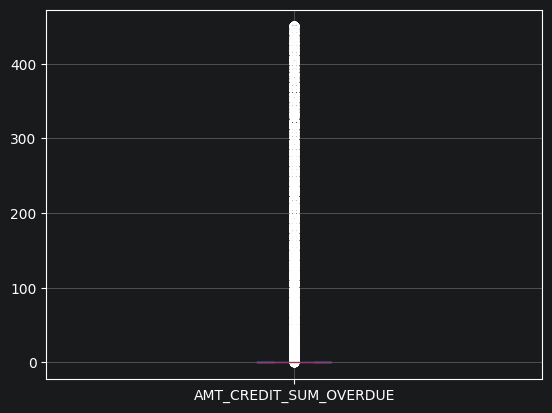

In [75]:
bureau[["AMT_CREDIT_SUM_OVERDUE"]].boxplot()
plt.show()

In [76]:
application_train.shape

(307511, 176)

In [77]:
(application_train["bb_max_dpd"] >4).sum()

np.int64(2206)

In [78]:
(previous_application["AMT_APPLICATION"] == 0).sum()

np.int64(392402)

In [79]:
num_cols = application_train.select_dtypes(include='number').drop(columns='TARGET').columns.tolist()

# NaN Werte droppen für VIF Berechnung
X_vif = application_train[num_cols].dropna()

vif_data = pd.DataFrame({
    'Feature': num_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(num_cols))]
})
vif_data.sort_values('VIF', ascending=False)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
71,EXT_SOURCE_mean,inf
16,EXT_SOURCE_3,inf
15,EXT_SOURCE_2,inf
14,EXT_SOURCE_1,inf
19,YEARS_BEGINEXPLUATATION_AVG,1.029191e+07
...,...,...
104,inst_avg_payment_diff,1.583818e+00
98,cc_max_dpd,1.554162e+00
81,bureau_current_debt,1.413808e+00
67,AMT_REQ_CREDIT_BUREAU_WEEK,1.362469e+00


In [80]:
vif_data.loc[vif_data['Feature'].isin(["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"])]

,Feature,VIF
14,EXT_SOURCE_1,inf
15,EXT_SOURCE_2,inf
16,EXT_SOURCE_3,inf


In [82]:
createshit()